# 02 · Root finding: solving $f(x) = 0$

**Problem 1 - pipe friction.** For turbulent flow the Darcy friction factor $f$ satisfies the
implicit Colebrook equation
$$\frac{1}{\sqrt f} = -2\log_{10}\!\left(\frac{\varepsilon/D}{3.7} + \frac{2.51}{Re\sqrt f}\right),$$
which cannot be rearranged for $f$. We need it for a commercial-steel pipe ($\varepsilon$ = 0.045 mm,
$D$ = 50 mm) at $Re = 2\times10^5$.

**Problem 2 - particle settling.** How fast does a sand grain settle in water, when the drag
coefficient itself depends on the (unknown) velocity?

**What you will learn**

- rewrite an implicit engineering equation as g(x) = 0 and plot it before solving
- implement Newton's method and bisection, and choose between root finders
- measure the order of convergence from the iteration history
- recognise and avoid divergence

**Before you start:** notebook 00; derivatives; logarithms  ·  **Time:** about 60-75 min

Run the cells in order (Shift + Enter). Then change the numbers and run them again - that is how the
ideas sink in.

In [1]:
try:                      # on Google Colab (or anywhere engmath is missing): install it from GitHub
    import engmath
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engmath"], check=True)
import numpy as np
import matplotlib.pyplot as plt
import engmath
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")
from engmath import roots

## Write the problem as g(f) = 0 and look at it first

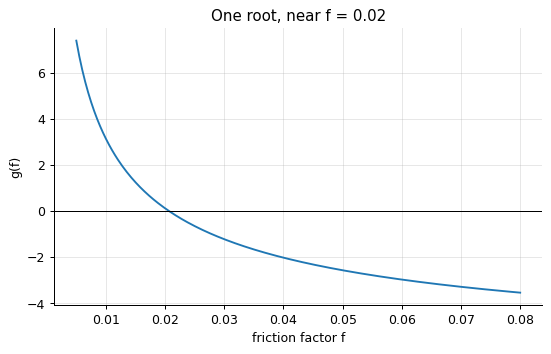

In [2]:
eps, D, Re = 0.045e-3, 0.05, 2e5

def colebrook(f):
    return 1/np.sqrt(f) + 2*np.log10(eps/D/3.7 + 2.51/(Re*np.sqrt(f)))

f = np.linspace(0.005, 0.08, 300)
plt.plot(f, colebrook(f)); plt.axhline(0, color="k", lw=0.8)
plt.xlabel("friction factor f"); plt.ylabel("g(f)"); plt.title("One root, near f = 0.02"); plt.show()

## Inside the algorithms
Newton's method replaces the curve by its tangent: $x_{k+1} = x_k - g(x_k)/g'(x_k)$. Bisection keeps
halving a bracket that contains a sign change. Both fit in a few lines:

In [3]:
def newton_by_hand(g, x, tol=1e-12, h=1e-8):
    for k in range(50):
        slope = (g(x + h) - g(x - h)) / (2 * h)     # numerical derivative
        step = g(x) / slope
        x = x - step
        print(f"iteration {k+1}: x = {x:.15f}")
        if abs(step) < tol:
            return x
    raise RuntimeError("Newton did not converge")

def bisection_by_hand(g, a, b, tol=1e-12):
    while b - a > tol:
        m = (a + b) / 2
        if g(a) * g(m) <= 0:
            b = m          # the sign change is in the left half
        else:
            a = m          # ... or in the right half
    return (a + b) / 2

newton_by_hand(colebrook, 0.02)
print("bisection:", bisection_by_hand(colebrook, 0.005, 0.08))

iteration 1: x = 0.020620573853059
iteration 2: x = 0.020635269368235
iteration 3: x = 0.020635277204567
iteration 4: x = 0.020635277204569
bisection: 0.02063527720472848


Watch the digits: each Newton iteration roughly doubles the number of correct ones. The library
versions add safeguards (zero slopes, non-finite values) and record the history:

In [4]:
show_source(roots.newton)

def newton(f, x0: float, df=None, tol: float = 1e-12, maxiter: int = 50) -> RootResult:
    """Newton-Raphson x_{k+1} = x_k - f(x_k)/f'(x_k). Quadratic convergence near a simple root,
    but it can diverge from a poor starting point. ``df`` defaults to a numerical derivative."""
    x = float(x0)
    hist = [x]
    for k in range(1, maxiter + 1):
        d = df(x) if df else derivative(f, x)
        if d == 0:
            return RootResult(x, False, k, hist, "Newton")
        step = f(x) / d
        x -= step
        hist.append(x)
        if not np.isfinite(x):
            return RootResult(x, False, k, hist, "Newton")
        if abs(step) < tol * max(1.0, abs(x)):
            return RootResult(x, True, k, hist, "Newton")
    return RootResult(x, False, maxiter, hist, "Newton")

## Four methods
| Method | Idea | Needs | Convergence |
|---|---|---|---|
| Bisection | halve a bracket | sign change | linear (1 bit/step) |
| Newton | follow the tangent | $f'$ and a good start | quadratic |
| Secant | tangent from two points | two starts | order 1.618 |
| Brent | bisection + interpolation | bracket | superlinear, guaranteed |

In [5]:
results = [roots.bisection(colebrook, 0.005, 0.08), roots.newton(colebrook, 0.02, tol=1e-15),
           roots.secant(colebrook, 0.01, 0.03, tol=1e-15), roots.brent(colebrook, 0.005, 0.08)]
for r in results:
    print(r)
from scipy.optimize import brentq
f_star = brentq(colebrook, 0.005, 0.08, xtol=1e-18)   # reference root, far more precise than the iterates

bisection: root = 0.0206352772045 (converged in 37 iterations)
Newton: root = 0.0206352772046 (converged in 5 iterations)
secant: root = 0.0206352772046 (converged in 8 iterations)
Brent: root = 0.0206352772046 (converged in 10 iterations)


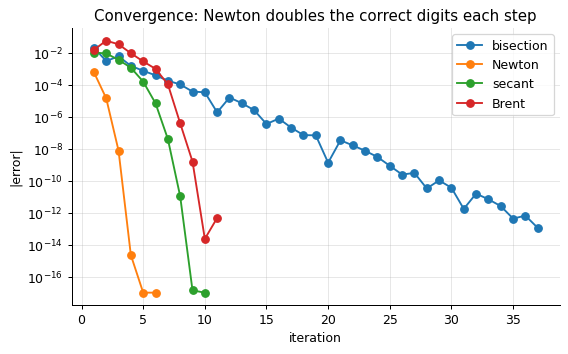

Newton   observed order 2.00
secant   observed order 1.61
bisection: error shrinks by a factor ~0.45 per step (linear convergence, ratio 1/2)


In [6]:
fig, ax = plt.subplots()
for r in results:
    err = np.abs(np.array(r.history) - f_star)
    ax.semilogy(np.arange(1, err.size + 1), np.maximum(err, 1e-17), "o-", label=r.method)
ax.set(xlabel="iteration", ylabel="|error|", title="Convergence: Newton doubles the correct digits each step")
ax.legend(); plt.show()
for r in results[1:3]:
    print(f"{r.method:<8} observed order {roots.convergence_order(r.history, f_star):.2f}")
e = np.abs(np.array(results[0].history) - f_star)
print(f"bisection: error shrinks by a factor ~{np.median(e[1:25]/e[:24]):.2f} per step (linear convergence, ratio 1/2)")

**Newton's weakness:** it can wander off from a bad start. Try it on $\arctan(x) = 0$ from $x_0 = 1.5$:

In [7]:
print(roots.newton(np.arctan, 1.3))    # converges
print(roots.newton(np.arctan, 1.5))    # diverges: the tangent overshoots further each step

Newton: root = -4.01687972939e-27 (converged in 7 iterations)
Newton: root = -2.38253142767e+13 (NOT converged in 8 iterations)


In practice: **bracket first, then use Brent** (`scipy.optimize.brentq`), or Newton only with a
good starting guess.

## The Moody diagram from a root finder
Solving Colebrook in a loop over $Re$ and $\varepsilon/D$ reproduces the turbulent part of the
Moody chart.

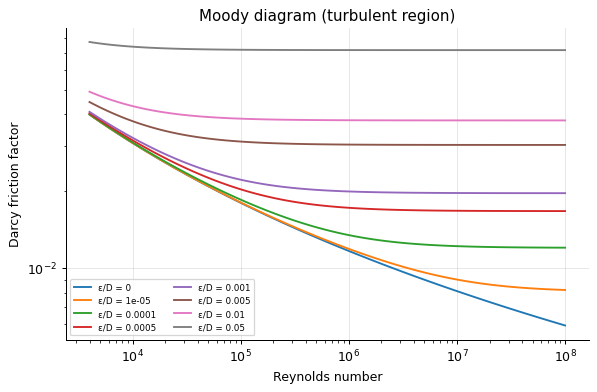

In [8]:
Re_range = np.logspace(3.6, 8, 120)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for rel in [0, 1e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2]:
    ff = [roots.brent(lambda f: 1/np.sqrt(f) + 2*np.log10(rel/3.7 + 2.51/(Rei*np.sqrt(f))), 1e-4, 1).root
          for Rei in Re_range]
    ax.loglog(Re_range, ff, label=f"ε/D = {rel:g}")
ax.set(xlabel="Reynolds number", ylabel="Darcy friction factor", title="Moody diagram (turbulent region)")
ax.legend(fontsize=7, ncol=2); plt.show()

## Problem 2: settling velocity of a sand grain
Force balance at terminal velocity:
$$\tfrac{1}{2}\rho_f v^2 C_D(Re)\,\tfrac{\pi d^2}{4} = (\rho_p - \rho_f)\,g\,\tfrac{\pi d^3}{6},
\qquad C_D = \frac{24}{Re}\left(1 + 0.15 Re^{0.687}\right)\ (Re < 800,\ \text{Schiller-Naumann}),$$
with $Re = \rho_f v d/\mu$. The unknown $v$ appears inside $C_D$: another implicit equation.

In [9]:
rho_f, mu, rho_p, g = 998.0, 1.0e-3, 2650.0, 9.81

def force_balance(v, d):
    Re = rho_f * v * d / mu
    Cd = 24/Re * (1 + 0.15*Re**0.687)
    return 0.5*rho_f*v**2*Cd*np.pi*d**2/4 - (rho_p - rho_f)*g*np.pi*d**3/6

for d_mm in (0.05, 0.1, 0.2, 0.5):
    d = d_mm * 1e-3
    v = roots.brent(lambda v: force_balance(v, d), 1e-6, 1.0).root
    v_stokes = (rho_p - rho_f)*g*d**2/(18*mu)
    print(f"d = {d_mm:4.2f} mm: v = {v*1000:6.2f} mm/s (Re = {rho_f*v*d/mu:5.2f}); Stokes' law would give {v_stokes*1000:6.2f} mm/s")

d = 0.05 mm: v =   2.18 mm/s (Re =  0.11); Stokes' law would give   2.25 mm/s
d = 0.10 mm: v =   7.98 mm/s (Re =  0.80); Stokes' law would give   9.00 mm/s
d = 0.20 mm: v =  24.83 mm/s (Re =  4.96); Stokes' law would give  36.01 mm/s
d = 0.50 mm: v =  78.56 mm/s (Re = 39.20); Stokes' law would give 225.08 mm/s


Stokes' law ($Re \ll 1$) is fine for fine silt but overpredicts badly for coarse sand, which is
exactly where the iterative solution is needed.

## Exercises
1. Solve the van der Waals equation $(P + a/V_m^2)(V_m - b) = RT$ for the molar volume of CO₂ at
   50 bar and 300 K ($a$ = 0.364 Pa·m⁶/mol², $b$ = 4.27×10⁻⁵ m³/mol). How many real roots are there
   at 280 K and 50 bar? Plot the cubic to find out.
2. Implement the fixed-point iteration $f_{k+1} = [-2\log_{10}(\ldots f_k\ldots)]^{-2}$ for Colebrook.
   Estimate its convergence order and compare with Newton.
3. Add Haaland's explicit approximation to the Moody diagram and plot its relative error.
4. **Implement it yourself:** write the *regula falsi* (false position) method: bisection, but split the bracket where the straight line through $(a, g(a))$ and $(b, g(b))$ crosses zero. Compare its iteration count with bisection on the Colebrook equation. Why can it be slow when one end of the bracket never moves?